# Análise de Viagens de Transporte Público

**Contexto**: Você é um analista de dados trabalhando para uma empresa de transporte público que opera linhas de ônibus em uma cidade. Foi fornecido um conjunto de dados com informações sobre viagens realizadas em diferentes linhas de ônibus. Sua tarefa é usar o Pandas para responder perguntas específicas e identificar padrões de uso do transporte.

**Dataset**: Crie um DataFrame com os seguintes dados (você pode copiar e colar no seu código):

```python
import pandas as pd

dados = {
    'Linha': ['Linha 1', 'Linha 2', 'Linha 1', 'Linha 3', 'Linha 2', 'Linha 3', 'Linha 1', 'Linha 2'],
    'Passageiros': [120, 85, 150, 60, 90, 70, 130, 100],
    'Data_Viagem': ['2023-05-01', '2023-05-01', '2023-05-02', '2023-05-02', '2023-05-03', '2023-05-03', '2023-05-04', '2023-05-04'],
    'Horário': ['Manhã', 'Tarde', 'Manhã', 'Noite', 'Tarde', 'Manhã', 'Noite', 'Manhã'],
    'Tipo_Dia': ['Dia Útil', 'Dia Útil', 'Dia Útil', 'Dia Útil', 'Dia Útil', 'Dia Útil', 'Feriado', 'Feriado'],
    'Distância_km': [10.5, 8.0, 10.5, 12.0, 8.0, 12.0, 10.5, 8.0]
}

df = pd.DataFrame(dados)
```

**Tarefas**:

1. **Exploração Inicial**:
   - Exiba as primeiras 5 linhas do DataFrame.
   - Verifique se há valores ausentes no conjunto de dados.
   - Mostre um resumo estatístico da coluna `Passageiros`.

2. **Cálculos Básicos**:
   - Crie uma nova coluna chamada `Passageiros_por_km` que calcule o número de passageiros por quilômetro percorrido (`Passageiros` / `Distância_km`).
   - Calcule o total de passageiros transportados em todas as viagens.

3. **Análise por Agrupamento**:
   - Agrupe os dados por `Linha` e calcule a média de `Passageiros` e a soma de `Distância_km`.
   - Agrupe os dados por `Tipo_Dia` e `Horário` e calcule o total de passageiros para cada combinação.

4. **Filtros**:
   - Filtre as viagens realizadas no horário da manhã com mais de 100 passageiros.
   - Filtre as viagens em dias úteis com distância superior a 10 km.

5. **Extra (Desafio)**:
   - Converta a coluna `Data_Viagem` para o formato datetime.
   - Crie uma nova coluna `Dia_Semana` que indique o dia da semana de cada viagem (ex.: Segunda, Terça, etc.).
   - Identifique qual dia da semana teve o maior número total de passageiros.

**Dicas**:
- Use `head()` para exibir as primeiras linhas e `describe()` para o resumo estatístico.
- Para cálculos de colunas derivadas, use operações vetoriais (ex.: `df['nova_coluna'] = df['coluna1'] / df['coluna2']`).
- Para trabalhar com datas, use `pd.to_datetime()` e `.dt.day_name()` (em inglês, ou traduza para português se necessário).
- Para agrupamentos, use `groupby()` com funções como `mean()`, `sum()` e `value_counts()`.

**Código Base para Começar**:
```python
import pandas as pd

# Criando o DataFrame
dados = {
    'Linha': ['Linha 1', 'Linha 2', 'Linha 1', 'Linha 3', 'Linha 2', 'Linha 3', 'Linha 1', 'Linha 2'],
    'Passageiros': [120, 85, 150, 60, 90, 70, 130, 100],
    'Data_Viagem': ['2023-05-01', '2023-05-01', '2023-05-02', '2023-05-02', '2023-05-03', '2023-05-03', '2023-05-04', '2023-05-04'],
    'Horário': ['Manhã', 'Tarde', 'Manhã', 'Noite', 'Tarde', 'Manhã', 'Noite', 'Manhã'],
    'Tipo_Dia': ['Dia Útil', 'Dia Útil', 'Dia Útil', 'Dia Útil', 'Dia Útil', 'Dia Útil', 'Feriado', 'Feriado'],
    'Distância_km': [10.5, 8.0, 10.5, 12.0, 8.0, 12.0, 10.5, 8.0]
}
df = pd.DataFrame(dados)

# Comece suas análises aqui
```

**O que você vai aprender**:
- Exploração de dados com resumo estatístico.
- Criação de colunas derivadas com cálculos.
- Agrupamento por múltiplas categorias.
- Filtros com condições combinadas.
- Manipulação de datas e extração de informações temporais (como dia da semana).

**Extra (Visualização)**:
Se quiser praticar visualização, crie um gráfico de barras mostrando o total de passageiros por horário. Use o seguinte código após a análise:

```python
import matplotlib.pyplot as plt

passageiros_por_horario = df.groupby('Horário')['Passageiros'].sum()
passageiros_por_horario.plot(kind='bar', color='#4682B4')
plt.title('Total de Passageiros por Horário')
plt.xlabel('Horário')
plt.ylabel('Total de Passageiros')
plt.show()
```

## 1. Configurações e Dependências

In [33]:
# dependencias
import sys
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print(f"""
=== VERSÕES ===
Python: {sys.version.split()[0]}
Pandas: {pd.__version__}
Numpy: {np.__version__}
Matplotlib: {matplotlib.__version__}
""")


=== VERSÕES ===
Python: 3.13.5
Pandas: 2.2.3
Numpy: 2.1.3
Matplotlib: 3.10.0



In [2]:
# configurações
pd.set_option('display.max_columns', 10)
pd.set_option('display.max_rows', 20)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)

## 2. Coleta de Dados

In [3]:
try:
    df=pd.DataFrame(
        {
            'Linha': ['Linha 1', 'Linha 2', 'Linha 1', 'Linha 3', 'Linha 2', 'Linha 3', 'Linha 1', 'Linha 2'],
            'Passageiros': [120, 85, 150, 60, 90, 70, 130, 100],
            'Data_Viagem': ['2023-05-01', '2023-05-01', '2023-05-02', '2023-05-02', '2023-05-03', '2023-05-03', '2023-05-04', '2023-05-04'],
            'Horário': ['Manhã', 'Tarde', 'Manhã', 'Noite', 'Tarde', 'Manhã', 'Noite', 'Manhã'],
            'Tipo_Dia': ['Dia Útil', 'Dia Útil', 'Dia Útil', 'Dia Útil', 'Dia Útil', 'Dia Útil', 'Feriado', 'Feriado'],
            'Distância_km': [10.5, 8.0, 10.5, 12.0, 8.0, 12.0, 10.5, 8.0]
        }
    )
    print("\n=== Dados Carregados ===" if df is not None else "\nErro." )
except Exception as e:
    raise ValueErro(f"Erro ao carregar DataFrame:\n{e}")


=== Dados Carregados ===


## 3. Tarefas

### 3.1 Exploração Inicial

In [4]:
# Exiba as primeiras 5 linhas do DataFrame.
df.head()

,Linha,Passageiros,Data_Viagem,Horário,Tipo_Dia,Distância_km
0,Linha 1,120,2023-05-01,Manhã,Dia Útil,10.50
1,Linha 2,85,2023-05-01,Tarde,Dia Útil,8.00
2,Linha 1,150,2023-05-02,Manhã,Dia Útil,10.50
3,Linha 3,60,2023-05-02,Noite,Dia Útil,12.00
4,Linha 2,90,2023-05-03,Tarde,Dia Útil,8.00


In [5]:
# Verifique se há valores ausentes no conjunto de dados.
df.isna().sum()

Linha           0
Passageiros     0
Data_Viagem     0
Horário         0
Tipo_Dia        0
Distância_km    0
dtype: int64

In [6]:
# Mostre um resumo estatístico da coluna `Passageiros`.
df['Passageiros'].describe().reset_index()

,index,Passageiros
0,count,8.00
1,mean,100.62
2,std,30.76
3,min,60.00
4,25%,81.25
5,50%,95.00
6,75%,122.50
7,max,150.00


### 3.2 Cálculos Básicos

In [7]:
# Crie uma nova coluna chamada `Passageiros_por_km` que calcule o número de passageiros por quilômetro percorrido (`Passageiros` / `Distância_km`).
df['Passageiros_por_km'] = df['Passageiros']/df['Distância_km']
df.head()

,Linha,Passageiros,Data_Viagem,Horário,Tipo_Dia,Distância_km,Passageiros_por_km
0,Linha 1,120,2023-05-01,Manhã,Dia Útil,10.50,11.43
1,Linha 2,85,2023-05-01,Tarde,Dia Útil,8.00,10.62
2,Linha 1,150,2023-05-02,Manhã,Dia Útil,10.50,14.29
3,Linha 3,60,2023-05-02,Noite,Dia Útil,12.00,5.00
4,Linha 2,90,2023-05-03,Tarde,Dia Útil,8.00,11.25


In [8]:
# Calcule o total de passageiros transportados em todas as viagens.
df['Passageiros'].sum()

np.int64(805)

### 3.3 Análise por Agrupamento

In [9]:
# Agrupe os dados por Linha e calcule a média de Passageiros e a soma de Distância_km.
df.groupby('Linha').agg(
    Média_Passageiros=('Passageiros', 'mean'),
    Total_Distância_km=('Distância_km', 'sum')
)


,Média_Passageiros,Total_Distância_km
Linha,,
Linha 1,133.33,31.50
Linha 2,91.67,24.00
Linha 3,65.00,24.00


In [10]:
# Agrupe os dados por Tipo_Dia e Horário e calcule o total de passageiros para cada combinação.
df.groupby(['Tipo_Dia', 'Horário'])['Passageiros'].sum().reset_index()

,Tipo_Dia,Horário,Passageiros
0,Dia Útil,Manhã,340
1,Dia Útil,Noite,60
2,Dia Útil,Tarde,175
3,Feriado,Manhã,100
4,Feriado,Noite,130


### 3.4 Filtros

In [11]:
# Filtre as viagens realizadas no horário da manhã com mais de 100 passageiros.
df[(df['Horário']=='Manhã') & (df['Passageiros']>100)]

,Linha,Passageiros,Data_Viagem,Horário,Tipo_Dia,Distância_km,Passageiros_por_km
0,Linha 1,120,2023-05-01,Manhã,Dia Útil,10.50,11.43
2,Linha 1,150,2023-05-02,Manhã,Dia Útil,10.50,14.29


In [12]:
# Filtre as viagens em dias úteis com distância superior a 10 km.
df[(df['Tipo_Dia']=='Dia Útil') & (df['Distância_km']>10)]

,Linha,Passageiros,Data_Viagem,Horário,Tipo_Dia,Distância_km,Passageiros_por_km
0,Linha 1,120,2023-05-01,Manhã,Dia Útil,10.50,11.43
2,Linha 1,150,2023-05-02,Manhã,Dia Útil,10.50,14.29
3,Linha 3,60,2023-05-02,Noite,Dia Útil,12.00,5.00
5,Linha 3,70,2023-05-03,Manhã,Dia Útil,12.00,5.83


## 4. Extra (Desafio)

In [19]:
# Converta a coluna Data_Viagem para o formato datetime.
df['Data_Viagem'] = pd.to_datetime(df['Data_Viagem'])

In [21]:
df.dtypes

Linha                         object
Passageiros                    int64
Data_Viagem           datetime64[ns]
Horário                       object
Tipo_Dia                      object
Distância_km                 float64
Passageiros_por_km           float64
dtype: object

In [22]:
# Crie uma nova coluna Dia_Semana que indique o dia da semana de cada viagem (ex.: Segunda, Terça, etc.).
df['Dia_Semana'] = df['Data_Viagem'].dt.day_name()

In [24]:
df.sample()

,Linha,Passageiros,Data_Viagem,Horário,Tipo_Dia,Distância_km,Passageiros_por_km,Dia_Semana
4,Linha 2,90,2023-05-03,Tarde,Dia Útil,8.00,11.25,Wednesday


In [25]:
dias_semana_pt = {
    'Monday': 'Segunda-feira',
    'Tuesday': 'Terça-feira',
    'Wednesday': 'Quarta-feira',
    'Thursday': 'Quinta-feira',
    'Friday': 'Sexta-feira',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}

df['Dia_Semana'] = df['Data_Viagem'].dt.day_name().map(dias_semana_pt)

In [26]:
df.head()

,Linha,Passageiros,Data_Viagem,Horário,Tipo_Dia,Distância_km,Passageiros_por_km,Dia_Semana
0,Linha 1,120,2023-05-01,Manhã,Dia Útil,10.50,11.43,Segunda-feira
1,Linha 2,85,2023-05-01,Tarde,Dia Útil,8.00,10.62,Segunda-feira
2,Linha 1,150,2023-05-02,Manhã,Dia Útil,10.50,14.29,Terça-feira
3,Linha 3,60,2023-05-02,Noite,Dia Útil,12.00,5.00,Terça-feira
4,Linha 2,90,2023-05-03,Tarde,Dia Útil,8.00,11.25,Quarta-feira


In [28]:
# Identifique qual dia da semana teve o maior número total de passageiros.
df.groupby('Dia_Semana')['Passageiros'].sum()

Dia_Semana
Quarta-feira     160
Quinta-feira     230
Segunda-feira    205
Terça-feira      210
Name: Passageiros, dtype: int64

In [31]:
df.groupby('Dia_Semana')['Passageiros'].sum().idxmax(), df.groupby('Dia_Semana')['Passageiros'].sum().max()

('Quinta-feira', 230)

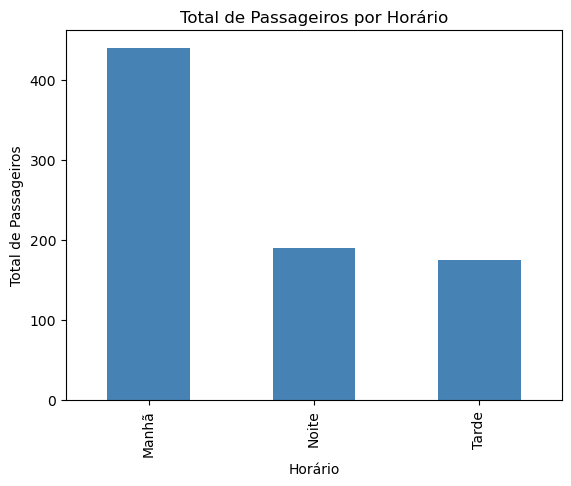

In [38]:
# crie um gráfico de barras mostrando o total de passageiros por horário
passageiros_por_horario = df.groupby('Horário')['Passageiros'].sum()
passageiros_por_horario.plot(kind='bar', color='#4682B4')
plt.title('Total de Passageiros por Horário')
plt.xlabel('Horário')
plt.ylabel('Total de Passageiros')
plt.show()